# 07 · A partial day: its error before it is scored, and the hour it is decided

A day of I-94 traffic observed at hours $H$ is classified by least squares
with its level profiled out. With the gap $\tilde g_H$ between the two
day-laws at those hours (level removed) and the residual covariance
$\Sigma$ of complete days, V11 gives its error exactly:

$$\mathrm{err}(H) = Q\left(\frac{|\tilde g_H|^2/2 \pm s^2 \log(\pi_1/\pi_0)}
{\sqrt{\tilde g_H^\top \Sigma_H \tilde g_H}}\right).$$

The only estimated input is $\Sigma$, and it carries the correlation of
neighbouring hours that V1's independent noise leaves out.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

1214 complete days; laws and Sigma from the first half
all 24 hours           predicted error: working-day law 0.0019, day-off law 0.0006
no night (06-23)       predicted error: working-day law 0.0086, day-off law 0.0189
no morning (12-23)     predicted error: working-day law 0.2279, day-off law 0.2530
no evening (00-11)     predicted error: working-day law 0.0032, day-off law 0.0015
six scattered hours    predicted error: working-day law 0.0018, day-off law 0.0001


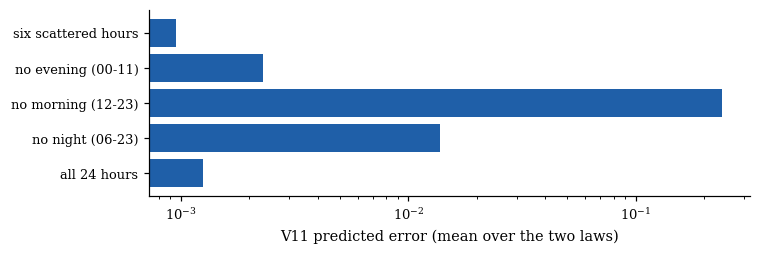

In [2]:
from experiments.realdata import partial
from lrdsr.theory.partial import masked_error

Y = partial.complete_days("traffic")
clf, F, Sigma, lab = partial.fit_half(Y[: len(Y) // 2], seed=11)
g = F[:, 1] - F[:, 0]
s2 = float(clf.sigma_[0] ** 2); L = float(clf.log_prior_[1] - clf.log_prior_[0])
print(f"{len(Y)} complete days; laws and Sigma from the first half")
errs = {}
for name, H in {"all 24 hours": np.arange(24), "no night (06-23)": np.arange(6, 24),
                "no morning (12-23)": np.arange(12, 24), "no evening (00-11)": np.arange(12),
                "six scattered hours": np.array([1, 5, 9, 13, 17, 21])}.items():
    e = [masked_error(g[H], Sigma[k][np.ix_(H, H)], s2, L, truth=k) for k in (0, 1)]
    errs[name] = np.mean(e)
    print(f"{name:22s} predicted error: working-day law {e[1]:.4f}, day-off law {e[0]:.4f}")
fig, ax = plt.subplots(figsize=(7, 2.4))
ax.barh(list(errs), list(errs.values()), color=viz.regime_color(0))
ax.set(xscale="log", xlabel="V11 predicted error (mean over the two laws)"); fig.tight_layout()

The same number of hours can cost nothing or a great deal. The experiment
removes a 6- or 12-hour block at every start hour from every held-out day and
compares the prediction with what happens:

,dataset,block_hours,spearman,worst_start_predicted,worst_start_observed,min_observed,max_observed
0,bike,12,0.9547,12h@23,12h@23,0.0009,0.0424
1,bike,6,0.9210,6h@05,6h@04,0.0009,0.0313
2,traffic,12,0.9409,12h@00,12h@00,0.0000,0.1982
3,traffic,6,0.8601,6h@04,6h@04,0.0000,0.0170


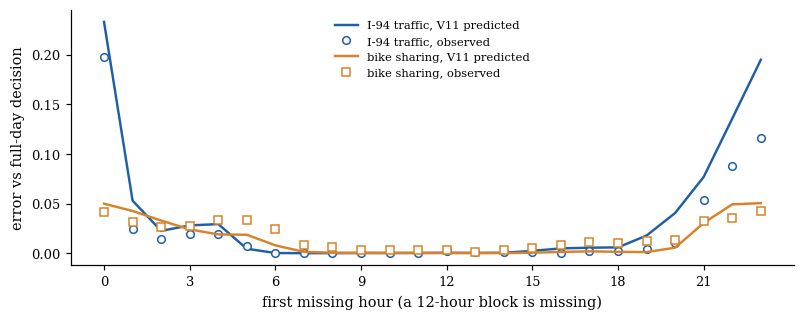

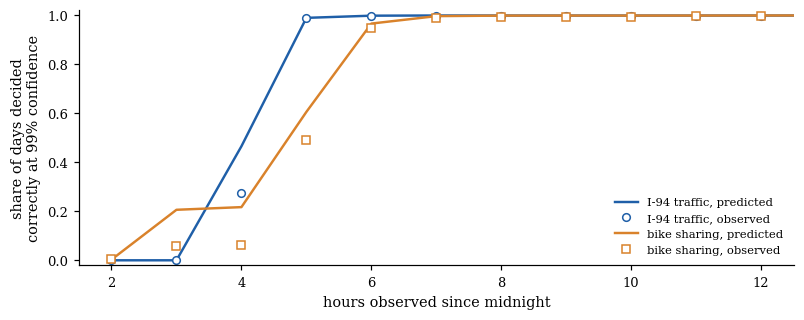

In [3]:
from analysis.figs_partial import v11_which_hours, v11_early_decision, online_kernel_birth
v11_which_hours(); v11_early_decision()
pd.read_csv(RES / "realdata" / "realdata_partial_ranking.csv")

## Streams with gaps, and a law the library cannot write

`OnlineLRDSR` takes a level nuisance, windows of any length and a kernel basis.
Every I-94 day in calendar order, the partial ones included:

In [4]:
pd.read_csv(RES / "online" / "online_ragged_traffic_summary.csv")

,arm,days,n,accuracy,buffered,births,final_regimes
0,all_days,complete,1154,0.9627,0.0251,1,3
1,all_days,partial,573,0.9634,0.0157,1,3
2,all_days,all,1727,0.9629,0.0220,1,3
3,complete_only,complete,1154,0.9601,0.0277,1,3
4,complete_only,all,1154,0.9601,0.0277,1,3


And a newcomer the term library cannot represent (`sin 4.6x` after `sin 4x`),
live for one stream, then over every seed:

library {'rho': 1.0, 'seed': 11, 'basis': 'library', 'control': False, 'births': 0, 'predicted_power': 0.7514550322572002, 'birth_delay': nan}
kernel {'rho': 1.0, 'seed': 11, 'basis': 'kernel', 'control': False, 'births': 1, 'predicted_power': 0.7514550322572002, 'birth_delay': 11, 'error_after_birth': 0.0, 'buffered_after_birth': 0.0}


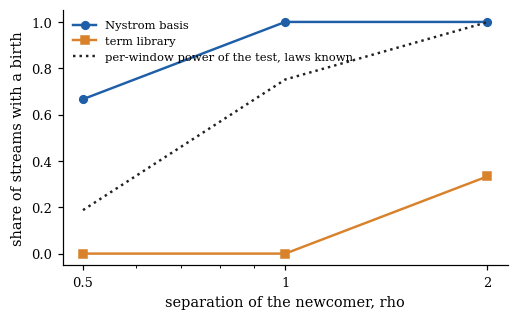

In [5]:
from experiments.online.ragged import birth_cell
for basis in ("library", "kernel"):
    print(basis, birth_cell(1.0, 11, basis, control=False))
online_kernel_birth();